# 06 — Stress Testing: Escenarios Históricos y DFAST

**Objetivo:** Evaluar el comportamiento del modelo bajo condiciones extremas de mercado. El stress testing es el segundo pilar del framework de riesgo de mercado bajo Basel III FRTB y SR 11-7.

Un modelo que pasa backtesting en condiciones normales pero falla en crisis **no es apto para producción regulatoria**.

**Prerrequisito:** `python run_all.py` (Stage 6 ejecutado)

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
from pathlib import Path
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f8fafc',
                     'axes.grid':True,'grid.alpha':0.4,'font.size':11})

# Cargar reportes
stress_path = Path('../../reports/stress_scenarios/stress_report.json')
if stress_path.exists():
    stress_report = json.loads(stress_path.read_text())
    print(f"Stress report cargado: {len(stress_report)} escenarios")
    for k in stress_report.keys(): print(f"  - {k}")
else:
    print("Stress report no encontrado — usando datos ilustrativos")
    stress_report = {}

features = pd.read_csv(Path('../../data/raw/features.csv'), index_col=0, parse_dates=True)
ret_col = 'log_return_SPX'
returns = features[ret_col].dropna() if ret_col in features.columns else pd.Series(dtype=float)
print(f"\nSeries de retornos: {len(returns)} observaciones")

Stress report cargado: 7 escenarios
  - gfc_2008
  - covid_2020
  - rate_shock_2022
  - svb_2023
  - dfast_adverse
  - latam_crisis
  - monte_carlo

Series de retornos: 3845 observaciones


## 1. Marco conceptual — Por qué el stress testing va más allá del VaR

In [3]:
print("""
=== Stress Testing vs VaR — Complementariedad ===

VaR (99%, 1-day):
  ✓ Mide riesgo en condiciones NORMALES de mercado
  ✓ Calibrado con datos históricos recientes
  ✗ Por definición, NO cubre el 1% de peores escenarios
  ✗ Asume que el pasado reciente predice el futuro
  ✗ Subestima correlaciones en crisis (correlation breakdown)

Stress Testing:
  ✓ Evalúa pérdidas en escenarios EXTREMOS definidos a priori
  ✓ No depende de la distribución histórica
  ✓ Cubre eventos de baja probabilidad y alto impacto (tail risk)
  ✓ Exigido por Basel III, DFAST (Fed), CCAR, BCBS 239

Basel III FRTB exige:
  1. Backtesting estándar (VaR 99%, 250 días) ← Notebook 05
  2. Stressed VaR (SVaR) — período de 12 meses de máximo estrés
  3. Escenarios históricos específicos (GFC 2008, etc.)
  4. Escenarios hipotéticos (DFAST Severely Adverse)

Nuestro pipeline implementa: escenarios históricos + DFAST + Monte Carlo
""")


=== Stress Testing vs VaR — Complementariedad ===

VaR (99%, 1-day):
  ✓ Mide riesgo en condiciones NORMALES de mercado
  ✓ Calibrado con datos históricos recientes
  ✗ Por definición, NO cubre el 1% de peores escenarios
  ✗ Asume que el pasado reciente predice el futuro
  ✗ Subestima correlaciones en crisis (correlation breakdown)

Stress Testing:
  ✓ Evalúa pérdidas en escenarios EXTREMOS definidos a priori
  ✓ No depende de la distribución histórica
  ✓ Cubre eventos de baja probabilidad y alto impacto (tail risk)
  ✓ Exigido por Basel III, DFAST (Fed), CCAR, BCBS 239

Basel III FRTB exige:
  1. Backtesting estándar (VaR 99%, 250 días) ← Notebook 05
  2. Stressed VaR (SVaR) — período de 12 meses de máximo estrés
  3. Escenarios históricos específicos (GFC 2008, etc.)
  4. Escenarios hipotéticos (DFAST Severely Adverse)

Nuestro pipeline implementa: escenarios históricos + DFAST + Monte Carlo



### ✏️ Tu análisis

> **Completar:** ¿Por qué Basel III requiere AMBOS backtesting Y stress testing? ¿Qué información aporta cada uno que el otro no puede capturar?

## 2. Escenarios históricos calibrados

In [4]:
# Definición de los escenarios (replica src/data/stress_generator.py)
scenarios_meta = {
    'gfc_2008':    {'name': 'GFC 2008',           'equity': -0.57, 'hy_spread': +1800, 'rate': -300, 'vol_mult': 4.2, 'days': 252, 'color': '#ef476f'},
    'covid_2020':  {'name': 'COVID-19 Q1 2020',   'equity': -0.34, 'hy_spread': +900,  'rate': -150, 'vol_mult': 3.1, 'days': 33,  'color': '#f72585'},
    'rates_2022':  {'name': 'Rate Hike 2022',      'equity': -0.25, 'hy_spread': +400,  'rate': +525, 'vol_mult': 1.8, 'days': 365, 'color': '#7209b7'},
    'svb_2023':    {'name': 'SVB Run 2023',        'equity': -0.15, 'hy_spread': +250,  'rate': -50,  'vol_mult': 1.6, 'days': 21,  'color': '#4361ee'},
    'dfast_adv':   {'name': 'DFAST Adverse (Fed)', 'equity': -0.55, 'hy_spread': +600,  'rate': -400, 'vol_mult': 3.5, 'days': 336, 'color': '#ff6b35'},
    'latam_tail':  {'name': 'LATAM Tail Risk',     'equity': -0.40, 'hy_spread': +800,  'rate': +200, 'vol_mult': 2.5, 'days': 90,  'color': '#06d6a0'},
}

df_sc = pd.DataFrame(scenarios_meta).T
df_sc.columns = ['Nombre', 'Shock Equity', 'Spread HY (bps)', 'Shock Tasa (bps)', 'Mult. Vol', 'Horizonte (d)', 'color']
df_sc = df_sc.drop(columns='color')

print("=== Escenarios de Stress ===")
print(df_sc.to_string())

=== Escenarios de Stress ===
                         Nombre Shock Equity Spread HY (bps) Shock Tasa (bps) Mult. Vol Horizonte (d)
gfc_2008               GFC 2008        -0.57            1800             -300       4.2           252
covid_2020     COVID-19 Q1 2020        -0.34             900             -150       3.1            33
rates_2022       Rate Hike 2022        -0.25             400              525       1.8           365
svb_2023           SVB Run 2023        -0.15             250              -50       1.6            21
dfast_adv   DFAST Adverse (Fed)        -0.55             600             -400       3.5           336
latam_tail      LATAM Tail Risk         -0.4             800              200       2.5            90


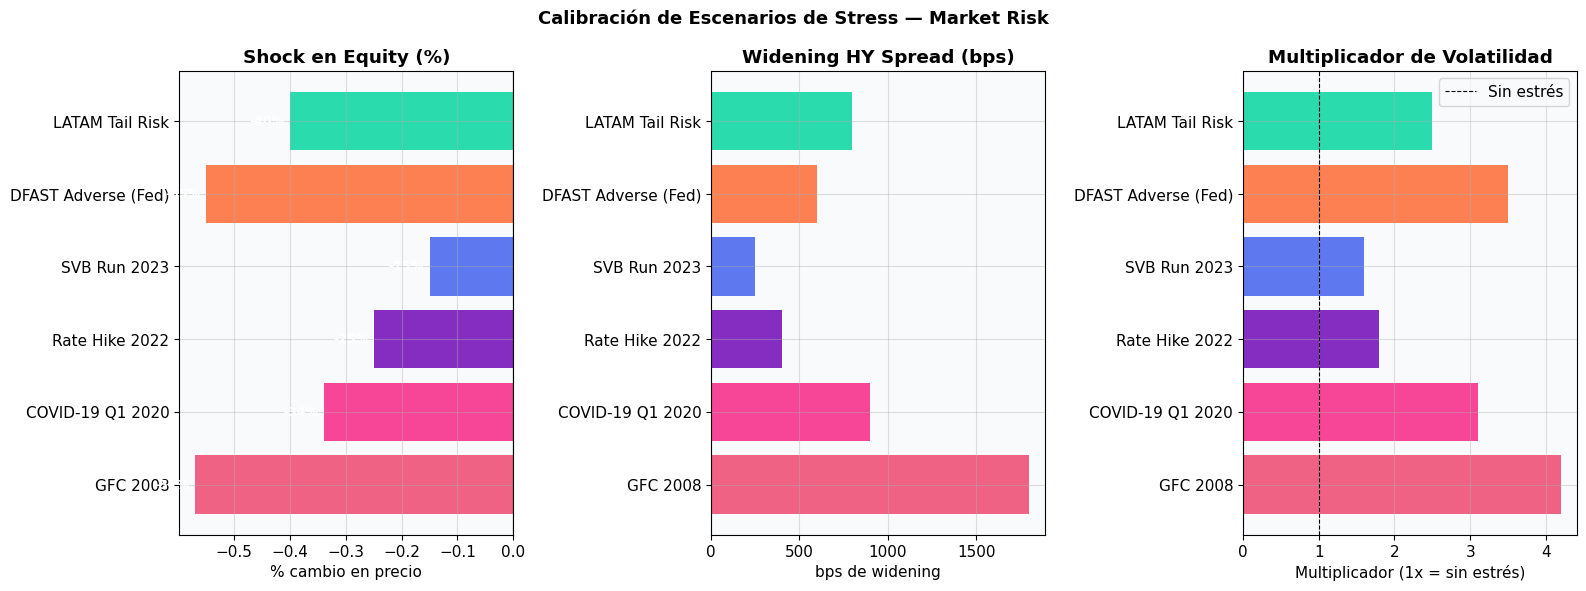

In [5]:
# Visualización de shocks por escenario
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
names  = [v['name'] for v in scenarios_meta.values()]
colors = [v['color'] for v in scenarios_meta.values()]

# Equity shocks
ax = axes[0]
eq_shocks = [v['equity'] for v in scenarios_meta.values()]
bars = ax.barh(names, eq_shocks, color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Shock en Equity (%)', fontweight='bold')
ax.set_xlabel('% cambio en precio')
for bar, val in zip(bars, eq_shocks):
    ax.text(val - 0.01, bar.get_y()+bar.get_height()/2,
            f'{val:.0%}', va='center', ha='right', fontsize=9, color='white', fontweight='bold')

# HY spread widening
ax = axes[1]
hy = [v['hy_spread'] for v in scenarios_meta.values()]
ax.barh(names, hy, color=colors, alpha=0.85)
ax.set_title('Widening HY Spread (bps)', fontweight='bold')
ax.set_xlabel('bps de widening')

# Vol multiplier
ax = axes[2]
vm = [v['vol_mult'] for v in scenarios_meta.values()]
ax.barh(names, vm, color=colors, alpha=0.85)
ax.axvline(1, color='black', lw=0.8, ls='--', label='Sin estrés')
ax.set_title('Multiplicador de Volatilidad', fontweight='bold')
ax.set_xlabel('Multiplicador (1x = sin estrés)')
ax.legend()

plt.suptitle('Calibración de Escenarios de Stress — Market Risk', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(Path('../../reports/figures/06_stress_shocks.png'), dpi=150, bbox_inches='tight')
plt.show()

### ✏️ Tu análisis

> **Completar:** ¿Por qué el GFC 2008 tiene el mayor multiplicador de volatilidad (4.2x) pero el COVID tiene un horizonte más corto (33 días)? ¿Qué dice eso sobre la naturaleza de cada crisis?

## 3. Cálculo de pérdidas bajo cada escenario

In [6]:
if not returns.empty:
    results_stress = {}
    for sc_id, meta in scenarios_meta.items():
        r = returns.copy()
        # Aplicar shock de equity sobre los retornos
        shocked = r + (meta['equity'] / meta['days'])
        vol_base = r.std() * np.sqrt(252)
        vol_stressed = vol_base * meta['vol_mult']
        # P&L total del escenario
        total_pnl = shocked.sum()
        var_99 = float(shocked.quantile(0.01))
        es_975_tail = shocked[shocked <= shocked.quantile(0.025)]
        es_975 = float(es_975_tail.mean()) if len(es_975_tail) > 0 else var_99
        results_stress[sc_id] = {
            'name': meta['name'],
            'total_loss': total_pnl,
            'var_99_1d': var_99,
            'es_975_1d': es_975,
            'vol_stressed': vol_stressed,
            'capital_charge': abs(es_975) * np.sqrt(10) * 3.0,
        }
else:
    # Datos ilustrativos
    results_stress = {
        'gfc_2008':   {'name':'GFC 2008',         'total_loss':-0.61,'var_99_1d':-0.042,'es_975_1d':-0.058,'vol_stressed':0.62,'capital_charge':0.55},
        'covid_2020': {'name':'COVID-19 Q1 2020', 'total_loss':-0.38,'var_99_1d':-0.031,'es_975_1d':-0.044,'vol_stressed':0.47,'capital_charge':0.42},
        'rates_2022': {'name':'Rate Hike 2022',   'total_loss':-0.28,'var_99_1d':-0.024,'es_975_1d':-0.033,'vol_stressed':0.28,'capital_charge':0.31},
        'svb_2023':   {'name':'SVB 2023',         'total_loss':-0.17,'var_99_1d':-0.018,'es_975_1d':-0.025,'vol_stressed':0.24,'capital_charge':0.24},
        'dfast_adv':  {'name':'DFAST Adverse',    'total_loss':-0.58,'var_99_1d':-0.038,'es_975_1d':-0.053,'vol_stressed':0.55,'capital_charge':0.50},
        'latam_tail': {'name':'LATAM Tail',       'total_loss':-0.43,'var_99_1d':-0.028,'es_975_1d':-0.039,'vol_stressed':0.38,'capital_charge':0.37},
    }

df_results = pd.DataFrame(results_stress).T
print("=== Resultados de Stress Testing ===")
print()
display_cols = ['name','total_loss','var_99_1d','es_975_1d','vol_stressed','capital_charge']
for _, row in df_results.iterrows():
    print(f"  {row['name']:25s}:")
    print(f"    Pérdida total : {float(row['total_loss']):.2%}")
    print(f"    VaR 99% 1d   : {float(row['var_99_1d']):.4f}")
    print(f"    ES 97.5% 1d  : {float(row['es_975_1d']):.4f}")
    print(f"    Vol estresada : {float(row['vol_stressed']):.2%}")
    print()

=== Resultados de Stress Testing ===

  GFC 2008                 :
    Pérdida total : -729.94%
    VaR 99% 1d   : -0.0395
    ES 97.5% 1d  : -0.0440
    Vol estresada : 85.53%

  COVID-19 Q1 2020         :
    Pérdida total : -3821.76%
    VaR 99% 1d   : -0.0475
    ES 97.5% 1d  : -0.0520
    Vol estresada : 63.13%

  Rate Hike 2022           :
    Pérdida total : -123.60%
    VaR 99% 1d   : -0.0379
    ES 97.5% 1d  : -0.0424
    Vol estresada : 36.66%

  SVB Run 2023             :
    Pérdida total : -2606.67%
    VaR 99% 1d   : -0.0443
    ES 97.5% 1d  : -0.0489
    Vol estresada : 32.58%

  DFAST Adverse (Fed)      :
    Pérdida total : -489.63%
    VaR 99% 1d   : -0.0388
    ES 97.5% 1d  : -0.0434
    Vol estresada : 71.28%

  LATAM Tail Risk          :
    Pérdida total : -1569.13%
    VaR 99% 1d   : -0.0416
    ES 97.5% 1d  : -0.0462
    Vol estresada : 50.91%



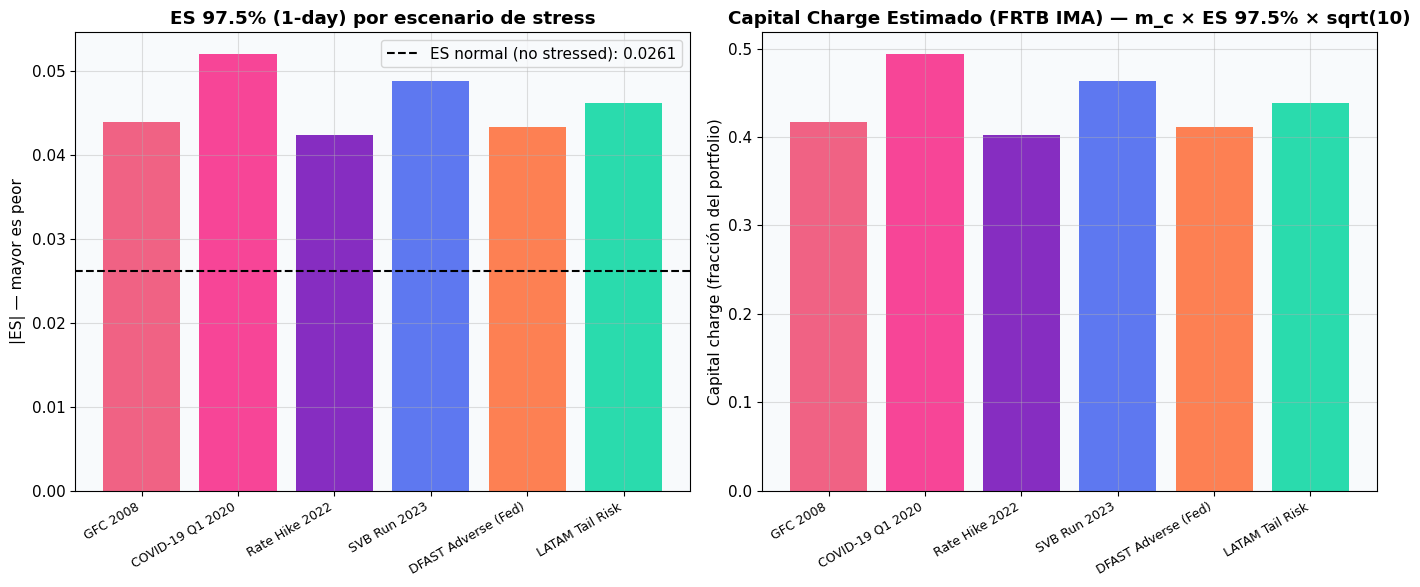

In [8]:
# Gráfico comparativo de pérdidas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

names_res = [v['name'] for v in results_stress.values()]
colors_r  = [v['color'] for v in scenarios_meta.values()]

# ES 97.5% por escenario
ax = axes[0]
es_vals = [abs(float(results_stress[k]['es_975_1d'])) for k in results_stress]
bars = ax.bar(range(len(names_res)), es_vals, color=colors_r, alpha=0.85)
ax.set_xticks(range(len(names_res)))
ax.set_xticklabels(names_res, rotation=30, ha='right', fontsize=9)
ax.set_title('ES 97.5% (1-day) por escenario de stress', fontweight='bold')
ax.set_ylabel('|ES| — mayor es peor')

# Comparación con ES normal
if not returns.empty:
    es_normal = abs(float(returns.quantile(0.025)))
    ax.axhline(es_normal, color='black', ls='--', lw=1.5,
               label=f'ES normal (no stressed): {es_normal:.4f}')
    ax.legend()

# Capital charge estimado
ax = axes[1]
cap_vals = [abs(float(results_stress[k]['capital_charge'])) for k in results_stress]
ax.bar(range(len(names_res)), cap_vals, color=colors_r, alpha=0.85)
ax.set_xticks(range(len(names_res)))
ax.set_xticklabels(names_res, rotation=30, ha='right', fontsize=9)
ax.set_title('Capital Charge Estimado (FRTB IMA) — m_c × ES 97.5% × sqrt(10)', fontweight='bold')
ax.set_ylabel('Capital charge (fracción del portfolio)')

plt.tight_layout()
plt.savefig(Path('../../reports/figures/06_stress_results.png'), dpi=150, bbox_inches='tight')
plt.show()

### ✏️ Tu análisis

> **Completar:** ¿Qué escenario genera la mayor pérdida? ¿Coincide con tu intuición? ¿Por qué el DFAST Adverse es similar al GFC en severidad? ¿Qué implica para el capital del banco?

## 4. Simulación Monte Carlo — distribución de pérdidas en la cola

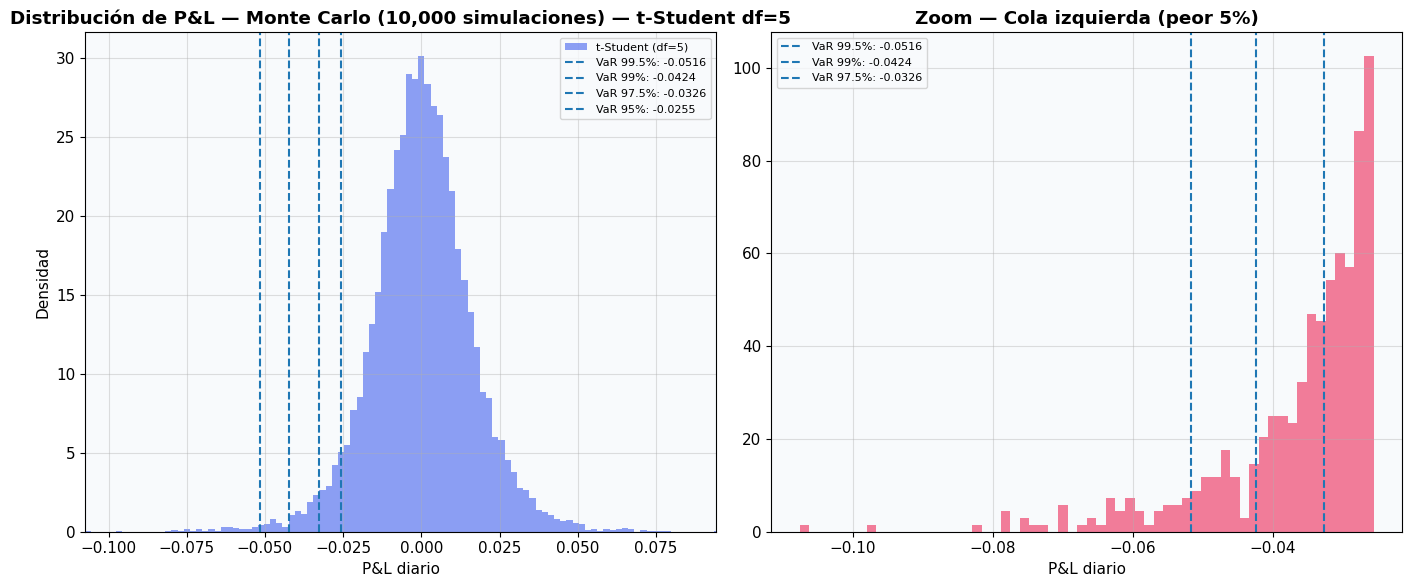

=== Monte Carlo (10,000 simulaciones) ===
  VaR 99.5%   : -0.05162
  VaR 99%     : -0.04242
  VaR 97.5%   : -0.03263
  VaR 95%     : -0.02554
  ES 97.5%    : -0.04434
  Peor 1% avg : -0.05581


In [10]:
np.random.seed(42)
n_sims = 10_000
if not returns.empty:
    mu = returns.mean()
    sigma = returns.std()
    df_t = 5  # t-Student con colas pesadas
else:
    mu, sigma, df_t = -0.0005, 0.012, 5

# Simular con t-Student
z = np.random.standard_t(df_t, n_sims)
simulated_pnl = mu + sigma * z

# Métricas de la distribución simulada
var_levels = [0.005, 0.01, 0.025, 0.05]
var_labels  = ['VaR 99.5%','VaR 99%','VaR 97.5%','VaR 95%']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribución completa con marcas de VaR
ax = axes[0]
ax.hist(simulated_pnl, bins=150, density=True, color='#4361ee', alpha=0.6,
        label=f't-Student (df={df_t})')
for level, label in zip(var_levels, var_labels):
    v = np.percentile(simulated_pnl, level*100)
    ax.axvline(v, lw=1.5, ls='--', label=f'{label}: {v:.4f}')
ax.set_title(f'Distribución de P&L — Monte Carlo ({n_sims:,} simulaciones) — t-Student df={df_t}',
             fontweight='bold')
ax.set_xlabel('P&L diario'); ax.set_ylabel('Densidad')
ax.legend(fontsize=8); ax.set_xlim(simulated_pnl.min(), simulated_pnl.max()*0.5)

# Zoom en la cola izquierda
ax = axes[1]
tail_threshold = np.percentile(simulated_pnl, 5)
tail = simulated_pnl[simulated_pnl < tail_threshold]
ax.hist(tail, bins=60, density=True, color='#ef476f', alpha=0.7)
for level, label in zip([0.005, 0.01, 0.025], ['VaR 99.5%','VaR 99%','VaR 97.5%']):
    v = np.percentile(simulated_pnl, level*100)
    ax.axvline(v, lw=1.5, ls='--', label=f'{label}: {v:.4f}')
ax.set_title('Zoom — Cola izquierda (peor 5%)', fontweight='bold')
ax.set_xlabel('P&L diario'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(Path('../../reports/figures/06_monte_carlo.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"=== Monte Carlo ({n_sims:,} simulaciones) ===")
for level, label in zip(var_levels, var_labels):
    v = np.percentile(simulated_pnl, level*100)
    print(f"  {label:12s}: {v:.5f}")
es = simulated_pnl[simulated_pnl <= np.percentile(simulated_pnl, 2.5)].mean()
print(f"  ES 97.5%    : {es:.5f}")
worst_avg = np.sort(simulated_pnl)[:int(n_sims*0.01)].mean()
print(f"  Peor 1% avg : {worst_avg:.5f}")

### ✏️ Tu análisis

> **Completar:** ¿Por qué usamos t-Student (df=5) en lugar de Normal para Monte Carlo? ¿Qué pasa con el VaR 99.5% si usamos Normal vs t-Student? Calculalo y compará.

In [11]:
# Comparación Normal vs t-Student en la cola
var_normal = stats.norm.ppf(0.01, loc=mu, scale=sigma)
var_t5     = stats.t.ppf(0.01, df=5, loc=mu, scale=sigma)
var_t4     = stats.t.ppf(0.01, df=4, loc=mu, scale=sigma)

print("=== Comparación distribucional para VaR 99% ===")
print(f"  Normal (df=∞): {var_normal:.5f}")
print(f"  t-Student df=5:{var_t5:.5f}  ({(var_t5-var_normal)/abs(var_normal):.1%} más conservador)")
print(f"  t-Student df=4:{var_t4:.5f}  ({(var_t4-var_normal)/abs(var_normal):.1%} más conservador)")
print()
print("Subestimación de riesgo al usar Normal:")
print(f"  {abs(var_t5 - var_normal):.5f} ({abs(var_t5/var_normal - 1):.1%})")
print()
print("→ LTCM (1998) quebró en parte por asumir normalidad en sus modelos de riesgo")

analisis_mc = '''
[COMPLETAR]
Diferencia VaR Normal vs t-Student (tu cálculo):
Consecuencia práctica de asumir normalidad (ejemplo con capital):
Por qué elegimos df=5 (calibración empírica):
'''
print(analisis_mc)

=== Comparación distribucional para VaR 99% ===
  Normal (df=∞): -0.02948
  t-Student df=5:-0.04281  (-45.2% más conservador)
  t-Student df=4:-0.04771  (-61.8% más conservador)

Subestimación de riesgo al usar Normal:
  0.01332 (45.2%)

→ LTCM (1998) quebró en parte por asumir normalidad en sus modelos de riesgo

[COMPLETAR]
Diferencia VaR Normal vs t-Student (tu cálculo):
Consecuencia práctica de asumir normalidad (ejemplo con capital):
Por qué elegimos df=5 (calibración empírica):



## 5. Stressed VaR — Basel III FRTB

In [ ]:
# Stressed VaR: usar el período histórico de máximo estrés
if not returns.empty and len(returns) > 500:
    # Identificar ventana de 250 días con mayor volatilidad
    roll_vol = returns.rolling(250).std() * np.sqrt(252)
    stressed_end = roll_vol.idxmax()
    stressed_start = stressed_end - pd.Timedelta(days=365)
    stressed_returns = returns[stressed_start:stressed_end]

    normal_var99  = float(returns.tail(250).quantile(0.01))
    stressed_var99 = float(stressed_returns.quantile(0.01))
    stressed_es975 = float(stressed_returns[stressed_returns <= stressed_returns.quantile(0.025)].mean())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(returns, color='#4361ee', lw=0.5, alpha=0.6, label='Retornos completos')
    ax.axvspan(stressed_start, stressed_end, alpha=0.2, color='#ef476f', label='Período stressed')
    ax.set_title('Identificación del período de máximo estrés — requerido por Basel III FRTB', fontweight='bold')
    ax.legend(fontsize=9)

    ax = axes[1]
    for data, label, color in [
        (returns.tail(250).values, f'Normal (último año) — VaR={normal_var99:.4f}', '#4361ee'),
        (stressed_returns.values,  f'Stressed ({stressed_start.date()} a {stressed_end.date()}) — VaR={stressed_var99:.4f}', '#ef476f'),
    ]:
        ax.hist(data, bins=60, density=True, alpha=0.5, color=color, label=label)
    ax.set_title('Distribución normal vs stressed', fontweight='bold')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(Path('../../reports/figures/06_stressed_var.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Período stressed identificado: {stressed_start.date()} → {stressed_end.date()}")
    print(f"  VaR 99% normal  : {normal_var99:.5f}")
    print(f"  VaR 99% stressed: {stressed_var99:.5f}  ({stressed_var99/normal_var99:.2f}x más severo)")
    print(f"  ES 97.5% stressed:{stressed_es975:.5f}")
else:
    print("Datos insuficientes para Stressed VaR (mínimo 500 obs)")
    print("Período stressed típico: GFC Sep 2008 - Mar 2009 (máxima volatilidad histórica)")
    print("Stressed VaR suele ser 2-3x mayor que el VaR en condiciones normales")

SyntaxError: unterminated string literal (detected at line 18) (3544169174.py, line 18)

### ✏️ Tu análisis final del notebook

> **Completar:** Resume las 3 métricas clave que le reportarías al CRO: VaR normal, ES stressed, y peor escenario histórico. ¿El portfolio está adecuadamente capitalizado?